In [1]:
from abc import ABC, abstractmethod
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

plt.rcParams["figure.figsize"] = (20, 10)

# Helper funcs

In [2]:
def is_leap_year(year: int) -> bool:
    return (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)


def act_act(start: date, end: date) -> float:
    if end <= start:
        return 0.0

    year_fraction = 0.0
    current = start

    while current < end:
        year_end = date(current.year + 1, 1, 1)
        period_end = min(year_end, end)

        days_in_period = (period_end - current).days
        days_in_year = 366 if is_leap_year(current.year) else 365

        year_fraction += days_in_period / days_in_year
        current = period_end

    return year_fraction

# Alap adatok
https://akk.hu/statisztika/allampapirok/alapadatok

In [3]:
# The date of data download is 1st Jan 2026. But the next business day will be 5th of Jan 2026. That is the actual date of the data.
today = date(2026, 1, 5)
alap = pd.read_excel("./data/alapadatok_20260101.xlsx")
alap

d:\git\GovBonds\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Értékpapír,ISIN kód,Rövid név,Deviza,Lejárat,Kibocsátás,Kibocsátás típusa,Kamatkonvenció,Kamatozás típusa,Kamat (%),Kintlévő állomány,Referencia görbe,Típus,Állomány dátum
0,A281022A11,HU0000402532,2028/A,HUF,2028-10-22,2011-03-02,Nyilvános,ACT/ACT,Fix,6.750,2.022857e+12,NaN,Kötvény,2025-12-15
1,B410329K11,US445545AF36,B410329K11,USD,2041-03-29,2011-03-29,Nyilvános,NaN,Fix,7.625,NaN,NaN,REP_HUN,NaT
2,A321202S13,HU0000402722,2032/S_BABA,HUF,2032-12-02,2013-12-02,Nyilvános,ACT/ACT,Változó,NaN,3.072270e+11,HUF CPI,BABA,2025-12-15
3,A330201S14,HU0000402771,2033/S_BABA,HUF,2033-02-01,2014-02-03,Nyilvános,ACT/ACT,Változó,NaN,2.897060e+10,HUF CPI,BABA,2025-12-15
4,A340201S15,HU0000403035,2034/S_BABA,HUF,2034-02-01,2015-02-02,Nyilvános,ACT/ACT,Változó,NaN,2.500028e+10,HUF CPI,BABA,2025-12-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,D260318,HU0000525233,D260318,HUF,2026-03-18,2025-11-19,Nyilvános,ACT/360,Fix,0.000,1.409596e+11,NaN,Diszkontkincstárjegy,2025-12-15
330,A301220Q25,HU0000407507,2030/Q5,HUF,2030-12-20,2025-11-13,Nyilvános,ACT/ACT,Fix,7.000,2.213770e+11,NaN,FixMÁP,2025-12-15
331,D261223,HU0000525241,D261223,HUF,2026-12-23,2025-12-23,Nyilvános,ACT/360,Fix,0.000,NaN,NaN,Diszkontkincstárjegy,NaT
332,A310123Q26,HU0000407515,2031/Q1,HUF,2031-01-23,2026-01-06,Nyilvános,ACT/ACT,Fix,7.000,NaN,NaN,FixMÁP,NaT


https://akk.hu/security/id=A281022A11

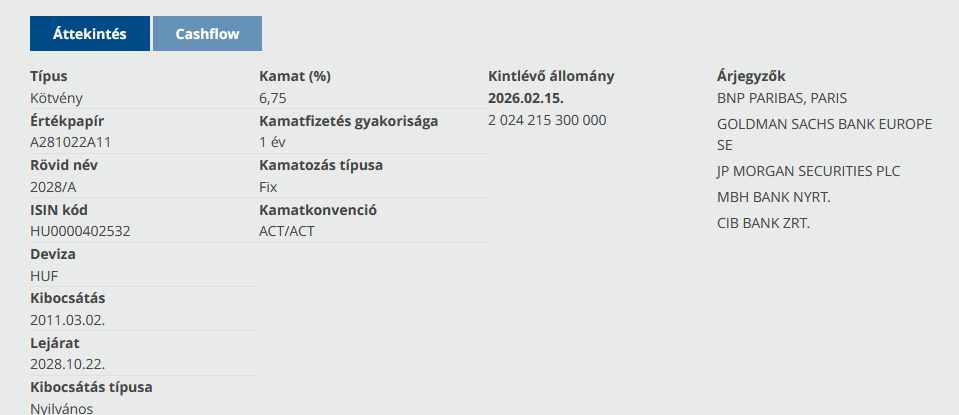

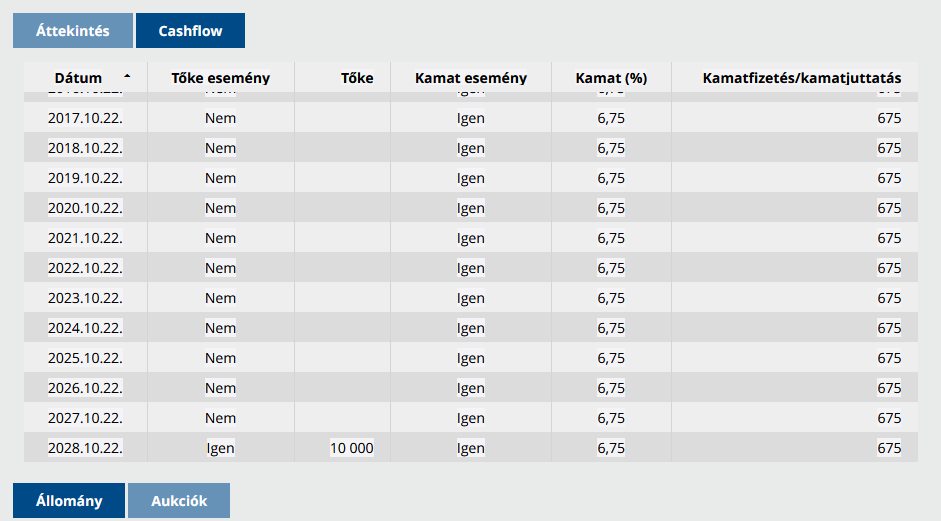

# Árfolyamok
https://www.allampapir.hu/kincstari_arfolyamjegyzes/FIX_MAP

In [4]:
price = pd.read_excel("./Prices/arfolyamjegyzes-MAP-2026-01-01.xlsx")
cols = [
    "Vételi Nettó\nÁrfolyam",
    "Vételi Hozam\n(ÁKK-ISMA)",
    "Vételi Hozam\n(EHM)",
    "Eladási Nettó\nÁrfolyam",
    "Eladási Hozam\n(ÁKK-ISMA)",
    "Eladási Hozam\n(EHM)",
    "Felhalmozott Kamat",
]
price[cols] = price[cols].replace(",", ".", regex=True).astype(float)
price

,Kötvény,Kibocsátás\ndátuma**,Lejárat,Vételi Nettó\nÁrfolyam,Vételi Hozam\n(ÁKK-ISMA),Vételi Hozam\n(EHM),Eladási Nettó\nÁrfolyam,Eladási Hozam\n(ÁKK-ISMA),Eladási Hozam\n(EHM),Felhalmozott Kamat
0,2026/J,2022-06-23,2026-02-20,99.0000,NaN,NaN,NaN,NaN,NaN,3.8892
1,2026/E,2020-09-02,2026-04-22,98.5941,6.46,6.32,98.7787,5.79,5.68,1.0603
2,2026/I,2021-01-20,2026-07-20,99.0000,NaN,NaN,NaN,NaN,NaN,2.2919
3,2026/F,2021-02-24,2026-08-26,97.0928,6.27,6.20,97.4996,5.58,5.53,0.5425
4,2026/N,2016-03-02,2026-09-22,99.0000,NaN,NaN,NaN,NaN,NaN,2.6017
...,...,...,...,...,...,...,...,...,...,...
65,2035/I1,2025-04-24,2035-05-24,99.0000,NaN,NaN,NaN,NaN,NaN,4.5589
66,2035/A,2023-09-13,2035-10-24,98.7251,7.18,7.18,103.5074,6.50,6.50,1.4000
67,2038/A,2018-02-07,2038-10-27,64.4147,7.39,7.39,68.4282,6.76,6.76,0.5753
68,2041/A,2020-01-22,2041-04-25,59.5627,7.54,7.53,63.8885,6.89,6.88,2.0959


# 2028/A

In [5]:
alap[alap["Rövid név"] == "2028/A"]

,Értékpapír,ISIN kód,Rövid név,Deviza,Lejárat,Kibocsátás,Kibocsátás típusa,Kamatkonvenció,Kamatozás típusa,Kamat (%),Kintlévő állomány,Referencia görbe,Típus,Állomány dátum
0,A281022A11,HU0000402532,2028/A,HUF,2028-10-22,2011-03-02,Nyilvános,ACT/ACT,Fix,6.75,2.022857e+12,NaN,Kötvény,2025-12-15


## Felhalmozott Kamat számítása (Accrued Interest)
$Felhalmozott Kamat = Kamat * yearFraction(legutóbbi kifizetés dátuma, ma)$

In [6]:
act_act(date(2025, 10, 22), today)

0.20547945205479454

In [7]:
calc_ai = alap[alap["Rövid név"] == "2028/A"]["Kamat (%)"][0] * act_act(
    date(2025, 10, 22), today
)
data_ai = price[price.Kötvény == "2028/A"]["Felhalmozott Kamat"].iloc[0]
calc_ai, data_ai

(np.float64(1.3869863013698631), np.float64(1.387))

## Hozam: y

In [8]:
kifizetes_datumok = [
    date(x, 10, 22)
    for x in range(2011, 2029)
    if date(x, 10, 22) > today and date(x, 10, 22) <= date(2028, 10, 22)
]
kifizetes_datumok

[datetime.date(2026, 10, 22),
 datetime.date(2027, 10, 22),
 datetime.date(2028, 10, 22)]

In [9]:
cfs = [
    106.75 if cf_date == date(2028, 10, 22) else 6.75 for cf_date in kifizetes_datumok
]
cfs

[6.75, 6.75, 106.75]

In [10]:
dts = [act_act(today, cf_date) for cf_date in kifizetes_datumok]
dts

[0.7945205479452054, 1.7945205479452055, 2.7950520248521595]

In [11]:
pv = 0
y = 6.60
for cf, dt in zip(cfs, dts):
    pv += cf / (1 + y / 100.0) ** dt

print(f"Bruttó ár: {pv}\nNettó ár: {pv - calc_ai}")

Bruttó ár: 101.72070018079359
Nettó ár: 100.33371387942373


In [12]:
price[
    price.Kötvény == "2028/A"
]  # Price difference is due to the finite representation of yield (y)

,Kötvény,Kibocsátás\ndátuma**,Lejárat,Vételi Nettó\nÁrfolyam,Vételi Hozam\n(ÁKK-ISMA),Vételi Hozam\n(EHM),Eladási Nettó\nÁrfolyam,Eladási Hozam\n(ÁKK-ISMA),Eladási Hozam\n(EHM),Felhalmozott Kamat
34,2028/A,2011-03-02,2028-10-22,100.3367,6.6,6.59,101.8719,5.99,5.98,1.387


In [13]:
def printif(debug, *args):
    if debug:
        print(*args)


class Bond:
    def __init__(
        self,
        interest: float,
        clean_price: float,
        maturity: date,
        today: date,
        name: str = "",
        debug=True,
    ):
        self._maturity = maturity
        self._interest = interest
        self._clean_price = clean_price
        self._today = today
        self._cf_dates = [
            cf_date
            for x in range(100)
            if (
                cf_date := date(
                    self._maturity.year - x, self._maturity.month, self._maturity.day
                )
            )
            > today
        ]
        self._cf_dates = self._cf_dates[::-1]  # (order by time)
        printif(debug, "cf_dates: ", self._cf_dates)
        self._dts = [act_act(self._today, cf_date) for cf_date in self._cf_dates]
        printif(debug, "dts: ", self._dts)
        self._cfs = [interest for x in self._cf_dates]
        self._cfs[-1] += 100
        printif(debug, "cfs: ", self._cfs)
        # Assuming yearly coupon
        prev_cf_date = date(
            self._cf_dates[0].year - 1, self._cf_dates[0].month, self._cf_dates[0].day
        )
        self._ai = self._interest * act_act(prev_cf_date, self._today)
        printif(debug, "Accrued interest: ", self._ai)
        printif(debug, "_clean_price: ", self._clean_price)
        self._dirty_price = self._clean_price + self._ai
        printif(debug, "Clean price:", self._clean_price)
        self._yield = scipy.optimize.broyden1(
            lambda x: self.yield_error(x), 1, f_tol=1e-10
        ).item()
        printif(debug, "yield=", self._yield)
        printif(debug, "==== Bond created ====\n")

    def reprice(self, y: float) -> float:
        pv_guess = 0.0
        for cf, dt in zip(self._cfs, self._dts):
            pv_guess += cf / (1 + y / 100) ** dt
        return pv_guess

    def yield_error(self, y: float) -> float:
        return self.reprice(y) - self._dirty_price

    # Useful for later
    def get_yield(self) -> float:
        return self._yield

    def get_maturity(self) -> date:
        return self._maturity

    def get_t0(self) -> date:
        return self._today

    def get_cfs(self) -> list[tuple[date, float]]:
        return list(zip(self._cf_dates, self._cfs))

    def get_dirty_price(self) -> float:
        return self._dirty_price

In [14]:
bond_2028A = Bond(6.75, 100.3367, date(2028, 10, 22), today)

cf_dates:  [datetime.date(2026, 10, 22), datetime.date(2027, 10, 22), datetime.date(2028, 10, 22)]
dts:  [0.7945205479452054, 1.7945205479452055, 2.7950520248521595]
cfs:  [6.75, 6.75, 106.75]
Accrued interest:  1.3869863013698631
_clean_price:  100.3367
Clean price: 100.3367
yield= 6.598800887808187
==== Bond created ====



# Risks
Present value is defined as:
$$PV=\sum_t\frac{CF(t)}{(1+y)^t}$$
Bond price is sensitive to yield change:
$$\frac{\partial PV}{\partial y} = -\sum_t \frac{t\cdot CF(t)}{(1+y)^{t+1}}$$
Hence change in present value:
$$\Delta PV \approx \frac{\partial PV}{\partial y}\Delta y$$
Relative change:
$$\frac{\Delta PV}{PV} \approx \frac{\frac{\partial PV}{\partial y}}{PV}\Delta y$$
Introduce modified duration: 
$$ModDur := -\frac{\frac{\partial PV}{\partial y}}{PV} = \sum_t \frac{t\cdot CF(t)}{PV\cdot(1+y)^{t+1}}$$
Modified duration describes: If yield increase by 1%, than bond's present value decrease by $ModDur$%.

In [15]:
def calc_mod_dur(self) -> float:
    pv = 0.0
    mod_dur = 0.0
    y = self.get_yield()
    for cf, dt in zip(self._cfs, self._dts):
        pv += cf / (1 + y / 100) ** dt
        mod_dur += dt * cf / (1 + y / 100) ** (dt + 1.0)
    mod_dur /= pv
    return mod_dur


Bond.calc_mod_dur = calc_mod_dur

# Calculating modified duration directly
print(f"Calculated modified duration: {bond_2028A.calc_mod_dur()}")

# Calculating price shock by shocking the yield
base_pv, base_y = bond_2028A.get_dirty_price(), bond_2028A._yield
shocked_y = base_y + 1.0
shocked_pv = bond_2028A.reprice(shocked_y)
print(
    f"base_pv={base_pv}, shocked_pv={shocked_pv}, relative change: {(shocked_pv-base_pv)/base_pv*100}%"
)

Calculated modified duration: 2.448130185425325
base_pv=101.72368630136985, shocked_pv=99.27612768236108, relative change: -2.406085257033999%


# 2051/G

In [16]:
bond_2051G = Bond(4.00, 59.1928, date(2051, 4, 28), today)

cf_dates:  [datetime.date(2026, 4, 28), datetime.date(2027, 4, 28), datetime.date(2028, 4, 28), datetime.date(2029, 4, 28), datetime.date(2030, 4, 28), datetime.date(2031, 4, 28), datetime.date(2032, 4, 28), datetime.date(2033, 4, 28), datetime.date(2034, 4, 28), datetime.date(2035, 4, 28), datetime.date(2036, 4, 28), datetime.date(2037, 4, 28), datetime.date(2038, 4, 28), datetime.date(2039, 4, 28), datetime.date(2040, 4, 28), datetime.date(2041, 4, 28), datetime.date(2042, 4, 28), datetime.date(2043, 4, 28), datetime.date(2044, 4, 28), datetime.date(2045, 4, 28), datetime.date(2046, 4, 28), datetime.date(2047, 4, 28), datetime.date(2048, 4, 28), datetime.date(2049, 4, 28), datetime.date(2050, 4, 28), datetime.date(2051, 4, 28)]
dts:  [0.3095890410958904, 1.3095890410958906, 2.3114454674751106, 3.3095890410958906, 4.30958904109589, 5.30958904109589, 6.31144546747511, 7.30958904109589, 8.30958904109589, 9.30958904109589, 10.31144546747511, 11.30958904109589, 12.30958904109589, 13.30958

In [17]:
# Calculating modified duration directly
print(f"Calculated modified duration: {bond_2051G.calc_mod_dur()}")

# Calculating price shock by shocking the yield
base_pv, base_y = bond_2051G.get_dirty_price(), bond_2051G._yield
shocked_y = base_y + 1.0
shocked_pv = bond_2051G.reprice(shocked_y)
print(
    f"base_pv={base_pv}, shocked_pv={shocked_pv}, relative change: {(shocked_pv-base_pv)/base_pv*100}%"
)

Calculated modified duration: 11.9960229339346
base_pv=61.95444383561644, shocked_pv=55.18154641932358, relative change: -10.932060715875954%


# Using all available data

In [18]:
map_fix = alap[
    (alap["Kamatozás típusa"] == "Fix") & (alap["Típus"] == "Kötvény")
].sort_values("Lejárat")
map_fix

,Értékpapír,ISIN kód,Rövid név,Deviza,Lejárat,Kibocsátás,Kibocsátás típusa,Kamatkonvenció,Kamatozás típusa,Kamat (%),Kintlévő állomány,Referencia görbe,Típus,Állomány dátum
25,A260422E20,HU0000404611,2026/E,HUF,2026-04-22,2020-09-02,Nyilvános,ACT/ACT,Fix,1.50,9.696505e+11,NaN,Kötvény,2025-12-15
43,A260826F21,HU0000404934,2026/F,HUF,2026-08-26,2021-02-24,Nyilvános,ACT/ACT,Fix,1.50,6.876874e+11,NaN,Kötvény,2025-12-15
175,A261021H23,HU0000406160,2026/H,HUF,2026-10-21,2023-01-18,Nyilvános,ACT/ACT,Fix,9.50,9.308164e+11,NaN,Kötvény,2025-12-15
10,A261222D17,HU0000403340,2026/D,HUF,2026-12-22,2017-05-24,Nyilvános,ACT/ACT,Fix,2.75,9.004306e+11,NaN,Kötvény,2025-12-15
6,A271027A16,HU0000403118,2027/A,HUF,2027-10-27,2016-01-13,Nyilvános,ACT/ACT,Fix,3.00,1.496361e+12,NaN,Kötvény,2025-12-15
97,A280323B22,HU0000405543,2028/B,HUF,2028-03-23,2022-01-19,Nyilvános,ACT/ACT,Fix,4.50,1.356190e+12,NaN,Kötvény,2025-12-15
0,A281022A11,HU0000402532,2028/A,HUF,2028-10-22,2011-03-02,Nyilvános,ACT/ACT,Fix,6.75,2.022857e+12,NaN,Kötvény,2025-12-15
24,A290523A20,HU0000404603,2029/A,HUF,2029-05-23,2020-06-24,Nyilvános,ACT/ACT,Fix,2.00,2.054584e+12,NaN,Kötvény,2025-12-15
316,A291128C25,HU0000407424,2029/C,HUF,2029-11-28,2025-07-30,Nyilvános,ACT/ACT,Fix,6.00,1.669507e+11,NaN,Kötvény,2025-12-15
17,A300821A19,HU0000403696,2030/A,HUF,2030-08-21,2019-02-20,Nyilvános,ACT/ACT,Fix,3.00,2.085857e+12,NaN,Kötvény,2025-12-15


In [19]:
map_all_info = pd.merge(
    map_fix, price, left_on="Rövid név", right_on="Kötvény", how="inner"
)
map_all_info

,Értékpapír,ISIN kód,Rövid név,Deviza,Lejárat_x,Kibocsátás,Kibocsátás típusa,Kamatkonvenció,Kamatozás típusa,Kamat (%),...,Kötvény,Kibocsátás\ndátuma**,Lejárat_y,Vételi Nettó\nÁrfolyam,Vételi Hozam\n(ÁKK-ISMA),Vételi Hozam\n(EHM),Eladási Nettó\nÁrfolyam,Eladási Hozam\n(ÁKK-ISMA),Eladási Hozam\n(EHM),Felhalmozott Kamat
0,A260422E20,HU0000404611,2026/E,HUF,2026-04-22,2020-09-02,Nyilvános,ACT/ACT,Fix,1.50,...,2026/E,2020-09-02,2026-04-22,98.5941,6.46,6.32,98.7787,5.79,5.68,1.0603
1,A260826F21,HU0000404934,2026/F,HUF,2026-08-26,2021-02-24,Nyilvános,ACT/ACT,Fix,1.50,...,2026/F,2021-02-24,2026-08-26,97.0928,6.27,6.20,97.4996,5.58,5.53,0.5425
2,A261021H23,HU0000406160,2026/H,HUF,2026-10-21,2023-01-18,Nyilvános,ACT/ACT,Fix,9.50,...,2026/H,2023-01-18,2026-10-21,102.1649,6.54,6.50,102.7021,5.85,5.82,1.9781
3,A261222D17,HU0000403340,2026/D,HUF,2026-12-22,2017-05-24,Nyilvános,ACT/ACT,Fix,2.75,...,2026/D,2017-05-24,2026-12-22,96.6854,6.41,6.40,97.2928,5.72,5.71,0.1055
4,A271027A16,HU0000403118,2027/A,HUF,2027-10-27,2016-01-13,Nyilvános,ACT/ACT,Fix,3.00,...,2027/A,2016-01-13,2027-10-27,94.2059,6.49,6.49,95.1952,5.87,5.87,0.5753
5,A280323B22,HU0000405543,2028/B,HUF,2028-03-23,2022-01-19,Nyilvános,ACT/ACT,Fix,4.50,...,2028/B,2022-01-19,2028-03-23,95.8411,6.57,6.56,97.0746,5.94,5.93,3.5507
6,A281022A11,HU0000402532,2028/A,HUF,2028-10-22,2011-03-02,Nyilvános,ACT/ACT,Fix,6.75,...,2028/A,2011-03-02,2028-10-22,100.3367,6.60,6.59,101.8719,5.99,5.98,1.3870
7,A290523A20,HU0000404603,2029/A,HUF,2029-05-23,2020-06-24,Nyilvános,ACT/ACT,Fix,2.00,...,2029/A,2020-06-24,2029-05-23,86.3972,6.62,6.61,88.1294,5.98,5.98,1.2438
8,A291128C25,HU0000407424,2029/C,HUF,2029-11-28,2025-07-30,Nyilvános,ACT/ACT,Fix,6.00,...,2029/C,2025-07-30,2029-11-28,97.8796,6.63,6.63,100.0177,5.99,5.99,0.6247
9,A300821A19,HU0000403696,2030/A,HUF,2030-08-21,2019-02-20,Nyilvános,ACT/ACT,Fix,3.00,...,2030/A,2019-02-20,2030-08-21,85.5976,6.72,6.72,87.8782,6.08,6.08,1.1260


In [20]:
map_all_info["Bond"] = map_all_info.apply(
    lambda x: Bond(
        x["Kamat (%)"],
        x["Vételi Nettó\nÁrfolyam"],
        x["Lejárat_x"].date(),
        today,
        x["Rövid név"],
        debug=False,
    ),
    axis=1,
)
map_all_info["yield_calc"] = map_all_info.apply(lambda x: x.Bond._yield, axis=1)
map_all_info["yield_error"] = (
    np.round(map_all_info["yield_calc"], 2) - map_all_info["Vételi Hozam\n(ÁKK-ISMA)"]
)
map_all_info

,Értékpapír,ISIN kód,Rövid név,Deviza,Lejárat_x,Kibocsátás,Kibocsátás típusa,Kamatkonvenció,Kamatozás típusa,Kamat (%),...,Vételi Nettó\nÁrfolyam,Vételi Hozam\n(ÁKK-ISMA),Vételi Hozam\n(EHM),Eladási Nettó\nÁrfolyam,Eladási Hozam\n(ÁKK-ISMA),Eladási Hozam\n(EHM),Felhalmozott Kamat,Bond,yield_calc,yield_error
0,A260422E20,HU0000404611,2026/E,HUF,2026-04-22,2020-09-02,Nyilvános,ACT/ACT,Fix,1.50,...,98.5941,6.46,6.32,98.7787,5.79,5.68,1.0603,<__main__.Bond object at 0x000002922BC25A90>,6.459956,0.00
1,A260826F21,HU0000404934,2026/F,HUF,2026-08-26,2021-02-24,Nyilvános,ACT/ACT,Fix,1.50,...,97.0928,6.27,6.20,97.4996,5.58,5.53,0.5425,<__main__.Bond object at 0x000002922BC28E90>,6.269965,0.00
2,A261021H23,HU0000406160,2026/H,HUF,2026-10-21,2023-01-18,Nyilvános,ACT/ACT,Fix,9.50,...,102.1649,6.54,6.50,102.7021,5.85,5.82,1.9781,<__main__.Bond object at 0x000002922BC290F0>,6.540027,0.00
3,A261222D17,HU0000403340,2026/D,HUF,2026-12-22,2017-05-24,Nyilvános,ACT/ACT,Fix,2.75,...,96.6854,6.41,6.40,97.2928,5.72,5.71,0.1055,<__main__.Bond object at 0x000002922BB5EC30>,6.409973,0.00
4,A271027A16,HU0000403118,2027/A,HUF,2027-10-27,2016-01-13,Nyilvános,ACT/ACT,Fix,3.00,...,94.2059,6.49,6.49,95.1952,5.87,5.87,0.5753,<__main__.Bond object at 0x000002922BB997B0>,6.490014,0.00
5,A280323B22,HU0000405543,2028/B,HUF,2028-03-23,2022-01-19,Nyilvános,ACT/ACT,Fix,4.50,...,95.8411,6.57,6.56,97.0746,5.94,5.93,3.5507,<__main__.Bond object at 0x000002922BB998C0>,6.563670,-0.01
6,A281022A11,HU0000402532,2028/A,HUF,2028-10-22,2011-03-02,Nyilvános,ACT/ACT,Fix,6.75,...,100.3367,6.60,6.59,101.8719,5.99,5.98,1.3870,<__main__.Bond object at 0x000002922BC78150>,6.598801,0.00
7,A290523A20,HU0000404603,2029/A,HUF,2029-05-23,2020-06-24,Nyilvános,ACT/ACT,Fix,2.00,...,86.3972,6.62,6.61,88.1294,5.98,5.98,1.2438,<__main__.Bond object at 0x000002922BC78450>,6.619927,0.00
8,A291128C25,HU0000407424,2029/C,HUF,2029-11-28,2025-07-30,Nyilvános,ACT/ACT,Fix,6.00,...,97.8796,6.63,6.63,100.0177,5.99,5.99,0.6247,<__main__.Bond object at 0x000002922BB2F200>,6.629972,0.00
9,A300821A19,HU0000403696,2030/A,HUF,2030-08-21,2019-02-20,Nyilvános,ACT/ACT,Fix,3.00,...,85.5976,6.72,6.72,87.8782,6.08,6.08,1.1260,<__main__.Bond object at 0x000002922BB2F110>,6.719965,0.00


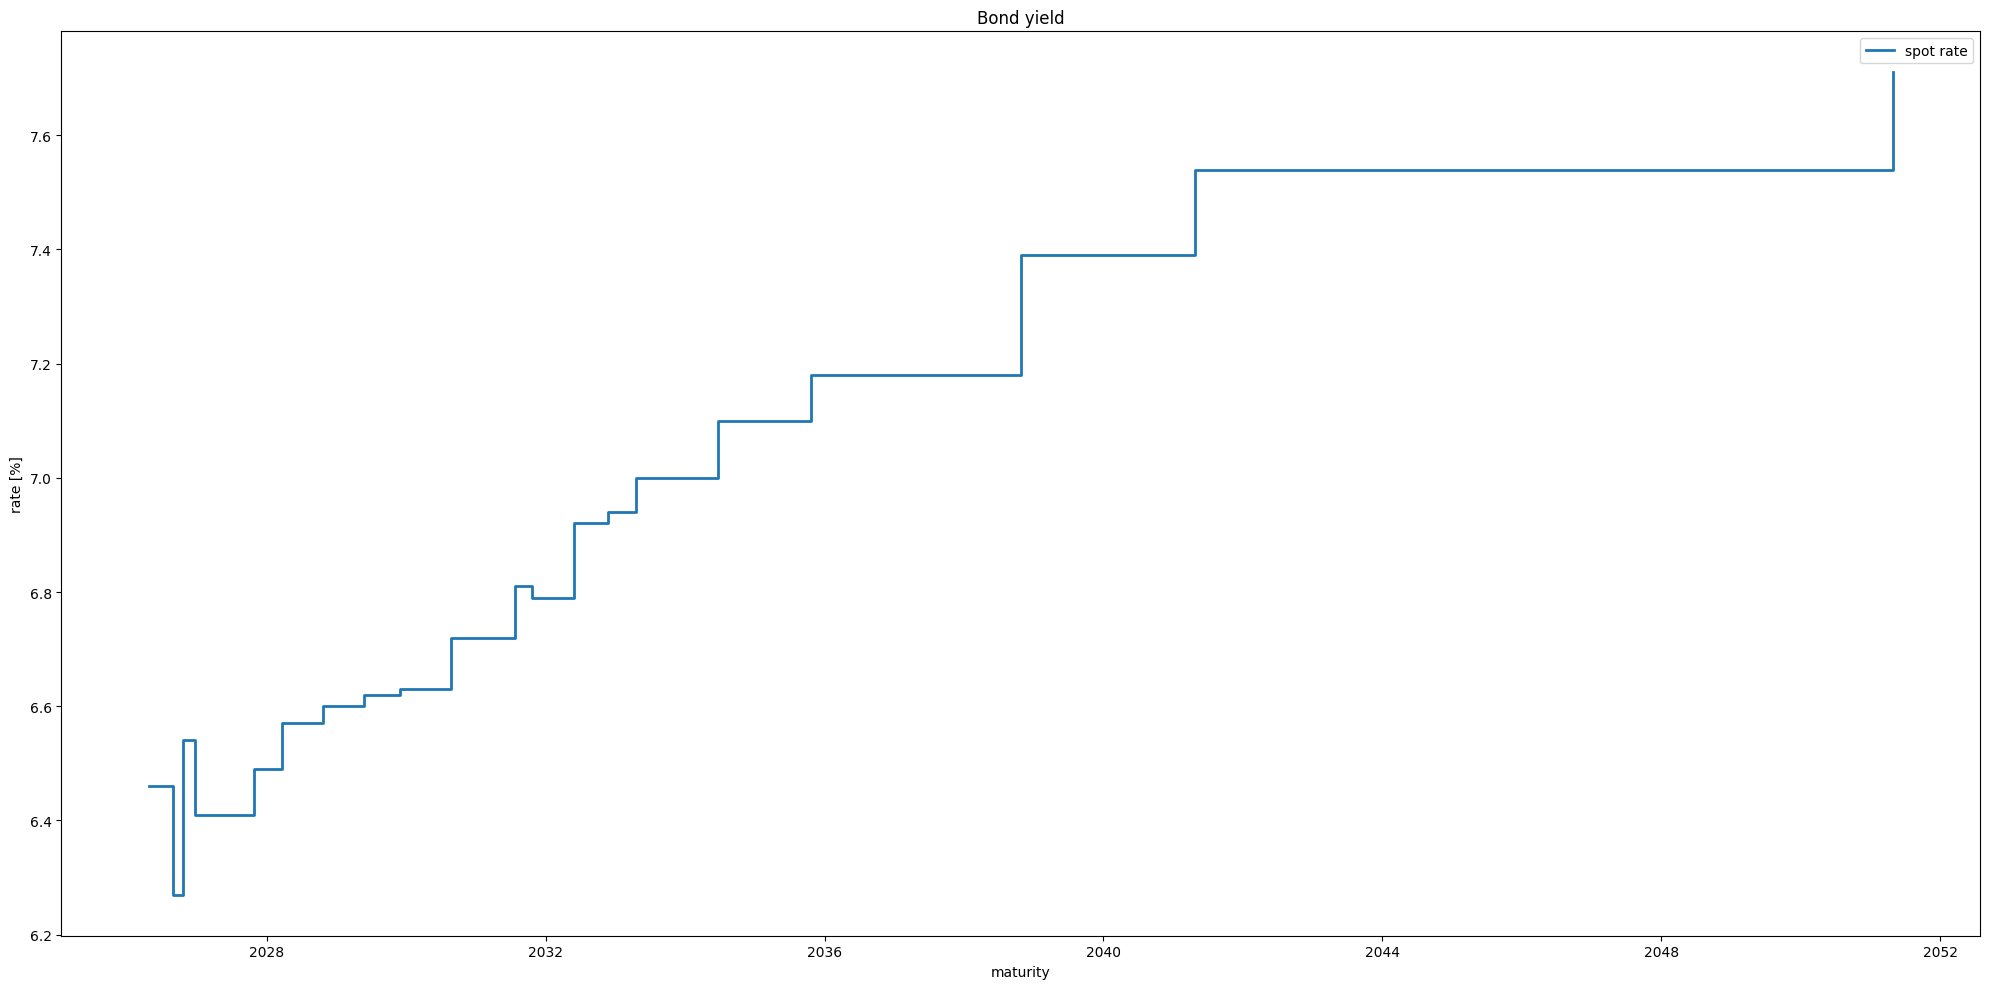

In [21]:
x = map_all_info["Lejárat_x"].dt.date
y = map_all_info["Vételi Hozam\n(ÁKK-ISMA)"]

# Create a step plot (piecewise constant)
plt.step(x, y, where="post", linewidth=2, label="spot rate")


plt.title("Bond yield")
plt.legend()
plt.xlabel("maturity")
plt.ylabel("rate [%]")
plt.tight_layout()
plt.show()

### Logarithmic interpolation
$$DF(0)=1.0$$
$$DF(t_{i+1})=DF(t_i)\cdot(1+r_{i+1})^{t_{i+1}-t_i}$$
for $t_i\leq t < t_{i+1}$:
$$DF(t)=DF(t_{i})\cdot(1+r_{i+1})^{t-t_{i}}$$
$$\ln(DF(t)) = \sum_{t_{i}<t}\left((t_i-t_{i-1})\ln(1+r_i)\right) + (t-t_i)\ln(1+r_{i+1})$$

In [22]:
class DFInterpolator(ABC):
    @abstractmethod
    def get_df(t: float) -> float:
        pass


class LogLinInterpolator(DFInterpolator):
    def __init__(self, times: list[float], rates: list[float]):
        if len(times) == 0:
            raise ValueError("No input for times.")
        if min(times) <= 0:
            raise ValueError("times contains non-pozitive number(s).")
        if times != sorted(times):
            raise ValueError("times is not sorted")
        self._t = np.array(times)
        if len(self._t) != len(times):
            raise ValueError(
                f"Size of times ({len(times)}) and size of dfs ({len(dfs)}) do not match."
            )
        self._rates = np.array(rates)

    def get_df(self, t: float) -> float:
        log_df = 0.0
        t_last = 0.0
        for i in range(len(self._t)):
            if t <= self._t[i]:
                log_df -= (t - t_last) * np.log(1 + self._rates[i])
                return np.exp(log_df)
            else:
                log_df -= (self._t[i] - t_last) * np.log(1 + self._rates[i])
                t_last = self._t[i]
        # right etrapolation
        log_df -= (t - t_last) * np.log(1 + self._rates[i])
        return np.exp(log_df)

    def update_rates(self, rates: list[float]) -> None:
        if len(rates) != len(self._rates):
            raise ValueError(
                f"Input rates size({len(rates)}) does not match current size ({len(self._rates)})"
            )
        else:
            self._rates = rates

# Bond Curve:
## Idea:
Calibrate a discount curve ($df(t)$) which can be used for any bond to discount it's cashflow to get back it's price.

In [23]:
class BondCurve_raw:
    def __init__(self, bonds: list[Bond]):
        self._t0 = bonds[0].get_t0()
        for b in bonds:
            if b.get_t0() != self._t0:
                raise ValueError(f"Inconsistent t0: {b.get_t0()} != {self._t0}")
        self._bonds = bonds
        self._bonds.sort(key=lambda x: x.get_maturity())
        mat_times = [act_act(self._t0, x.get_maturity()) for x in self._bonds]
        self._interpolator = LogLinInterpolator(mat_times, np.ones_like(mat_times))
        self.res = scipy.optimize.least_squares(
            lambda x: self.calc_error(x),
            np.ones_like(mat_times),
            bounds=(-0.999, np.inf),
            verbose=1,
        )
        self._interpolator.update_rates(self.res.x)

    def calc_error(self, rate_guesses: list[float]) -> float:
        # print(f"Guesses: {rate_guesses}",)
        errors = list()
        self._interpolator.update_rates(rate_guesses)
        for b in self._bonds:
            price = 0.0
            for date, cf in b.get_cfs():
                t = act_act(self._t0, date)
                df_t = self._interpolator.get_df(t)
                price += df_t * cf
            errors.append(price - b.get_dirty_price())
        return errors

    def get_df(self, d: date) -> float:
        t = act_act(self._t0, d)
        return self._interpolator.get_df(t)

In [24]:
my_curve = BondCurve_raw(map_all_info["Bond"].tolist())
my_curve.res.x

`gtol` termination condition is satisfied.
Function evaluations 17, initial cost 4.8060e+04, final cost 1.9438e-27, first-order optimality 8.12e-12.


array([0.06459956, 0.0610889 , 0.07671066, 0.05805846, 0.06579969,
       0.06914454, 0.06748237, 0.06707875, 0.06734803, 0.07224503,
       0.07519531, 0.05539749, 0.08410232, 0.07342576, 0.0774967 ,
       0.07807237, 0.08353571, 0.08062723, 0.08637361, 0.08449258])

In [25]:
map_all_info["Lejárat_x"].dt.date

0     2026-04-22
1     2026-08-26
2     2026-10-21
3     2026-12-22
4     2027-10-27
5     2028-03-23
6     2028-10-22
7     2029-05-23
8     2029-11-28
9     2030-08-21
10    2031-07-23
11    2031-10-22
12    2032-05-27
13    2032-11-24
14    2033-04-20
15    2034-06-22
16    2035-10-24
17    2038-10-27
18    2041-04-25
19    2051-04-28
Name: Lejárat_x, dtype: object

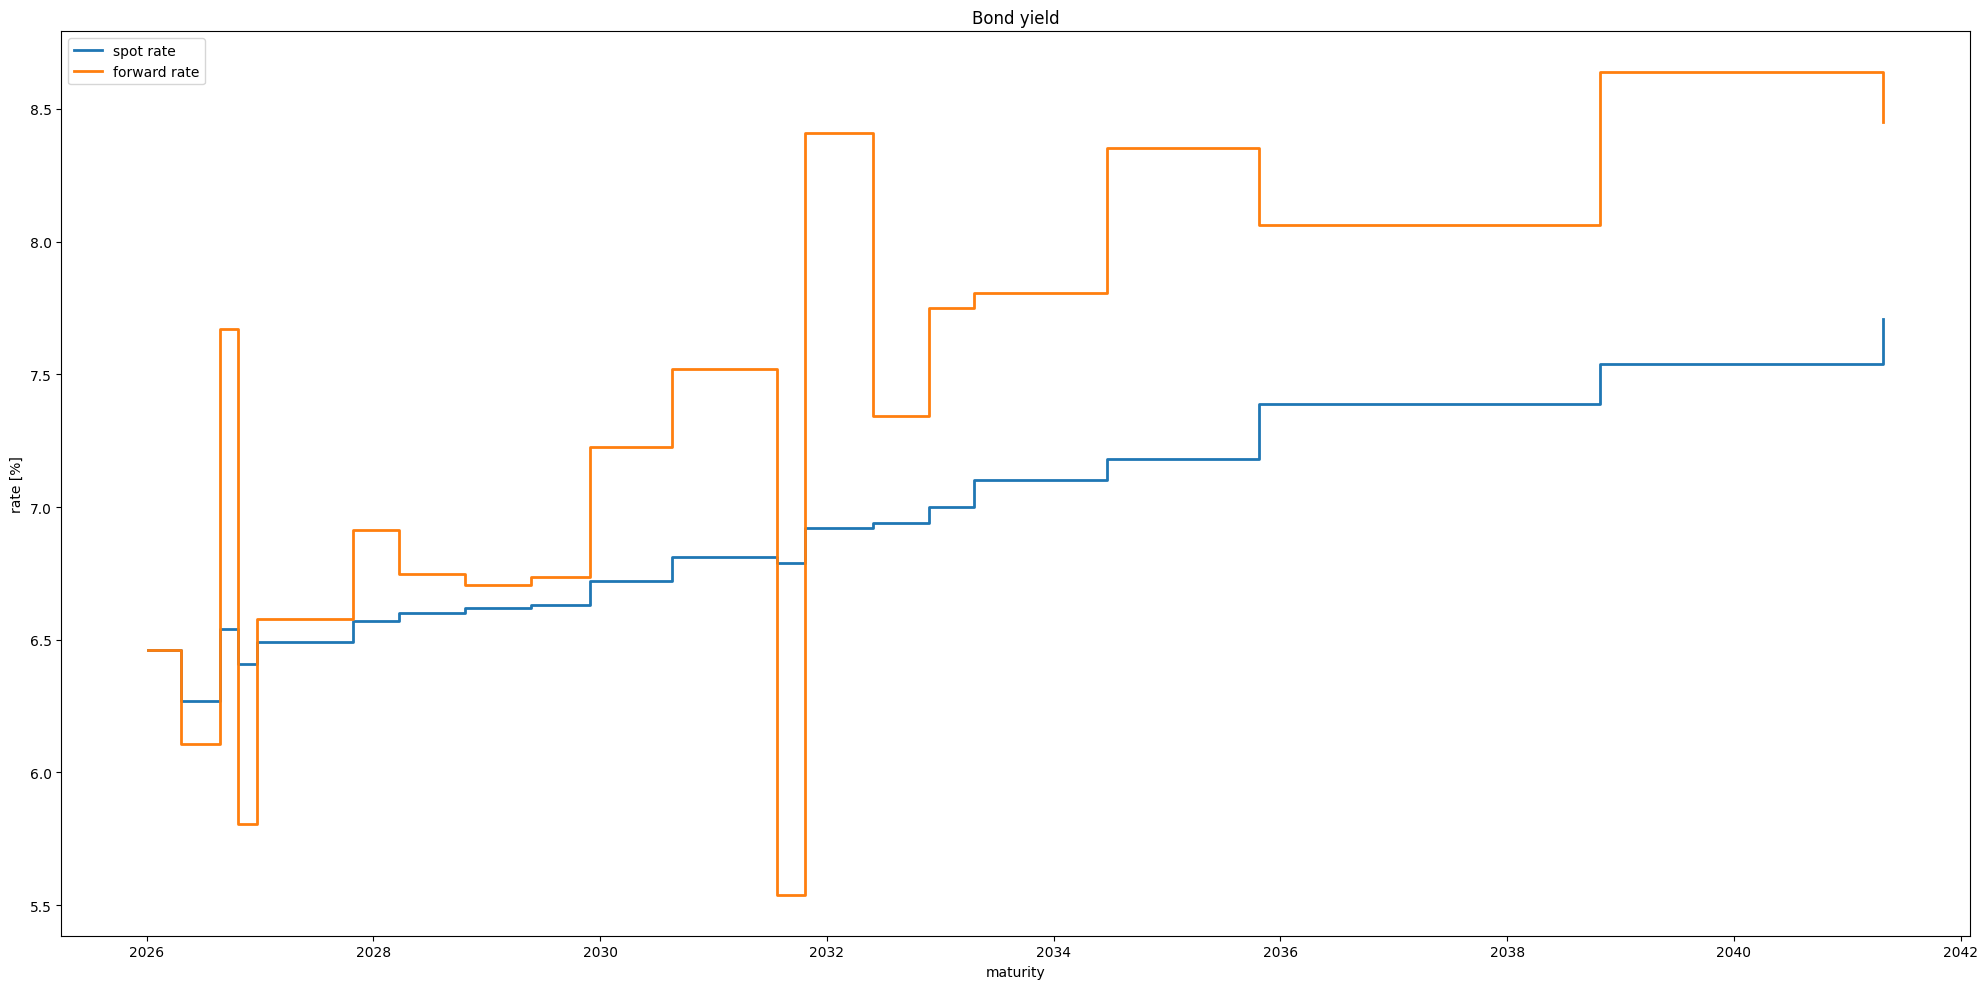

In [26]:
x = map_all_info["Lejárat_x"].dt.date
x = np.insert(x, 0, today)
x = x[:-1]
y = map_all_info["Vételi Hozam\n(ÁKK-ISMA)"]
y2 = my_curve.res.x * 100

# Create a step plot (piecewise constant)
plt.step(x, y, where="post", linewidth=2, label="spot rate")
plt.step(x, y2, where="post", linewidth=2, label="forward rate")

plt.title("Bond yield")
plt.legend()
plt.xlabel("maturity")
plt.ylabel("rate [%]")
plt.tight_layout()
plt.show()

# Gyakorlat:
Fix 3%, 50 mFt, 25 év, havi 237.106
Mennyi a törlesztők jelenértéke a Bond görbével diszkontálva?

## Using ModDur:
$$PV := \sum_{t} \frac{CF}{(1+y)^t}$$
$$ModDur := \sum_t \frac{t\cdot CF}{PV\cdot(1+y)^{t+1}}$$

In [27]:
# Quick calc
torl = 237106
pv = sum([torl/(1.03)**(i/12) for i in range(1, 25*12+1)])
mod_dur = sum([i/12*237106/pv/(1.03)**(i/12) for i in range(1, 25*12+1)])
print(f"mod_dur={mod_dur}, pv={pv}")
# Gov rate are between 6.0 and 8.5% -> ca. 4.5% higher -> pv with gov discount should be approx.:
pv*(1-mod_dur*0.045)

mod_dur=11.015994708862284, pv=50222751.495247744


25326341.082120795

In [28]:
torlesztes_datum = [today + relativedelta(months=i) for i in range(1, 25*12+1)]
pv = 0.0
for d in torlesztes_datum:
    pv += torl * my_curve.get_df(d)
float(pv)
    

32908590.08593834